# Custom Training Loops and Granular Control

While HeteroSymNN's high-level `Wrapper` agent makes training effortless, advanced use-cases (like custom learning rate scheduling, gradient clipping, multi-loss optimization, or customized dataloaders) require manual control over the execution loop.

This notebook demonstrates how to bypass the `Wrapper` and write a fully custom training loop using the low-level primitives exposed by `BaseNetwork`.

In [1]:
import sys
import os
# Setup path to import HeteroSymNN from the local directory
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from HeteroSymNN.Core.Nets import MLP
from HeteroSymNN.Core import losses
from HeteroSymNN.Core import optimizers
from HeteroSymNN.API import data_transformers as utils

## The Low-Level Primitives

The low-level API decouples the network forward pass, loss calculation, backward pass, and parameter updates:
- **Hardware Abstraction (`cast_arrays`)**: Seamlessly transfers data between CPU (NumPy) and GPU (CuPy) backends to match the model's compute configuration.
- **Forward Pass (`forward`)**: Propagates inputs layer-by-layer without implicit loss calculations.
- **Loss Computation (`loss_function.forward` / `loss_function.backward`)**: Evaluates the objective value and calculates output gradients.
- **Backward Pass (`backward`)**: Performs backpropagation through the network, accumulating layers gradients.
- **Optimizer Step (`update_params`)**: Updates parameters using the internal optimizer state.

## 1. Generating Data and Initializing the Network

We will generate a simple non-linear regression dataset and initialize an MLP without wrapping it. We manually configure the loss function, optimizer, and training batch size.

In [4]:
# Generate toy non-linear data
X = np.linspace(-3, 3, 1000).reshape(-1, 1)
y = np.tanh(X) * 0.5 + np.sin(X) * 0.5

# Initialize low-level network
network = MLP(
    nodes_structure=[1, 32, 32, 1],
    activation="tanh(num)",
    output_activation="num",
    loss_function=losses.MSELoss(),
    optimizer=optimizers.AdamOptimizer(learning_rate=0.01),
    batch_size=32
)

# Move network to CPU or GPU depending on backend configuration
network.to("device")

# Set up a MinMaxScaler for normalizing inputs manually
transformer = utils.MinMaxScaler()
X_scaled = transformer.fit_transform(X)

## 2. Implementing a Custom Mini-Batch Generator

To feed mini-batches into our custom loop, we write a simple python batch generator. This functions similarly to a simplified PyTorch `DataLoader`.

In [ ]:
def get_batches(X_data, y_data, batch_size, shuffle=True):
    indices = np.arange(len(X_data))
    if shuffle:
        np.random.shuffle(indices)
    for i in range(0, len(X_data), batch_size):
        batch_indices = indices[i:i+batch_size]
        yield X_data[:,batch_indices], y_data[:,batch_indices]

## 3. Writing the Custom Training Loop

Now we run the training loop explicitly. This gives us complete control over each step. 

Note that we also manually increment the standard tracking counters (`num_completed_train_iterations` and `num_completed_epochs`) to keep the network's metadata logs accurate.

In [7]:
epochs = 50
batch_size = 32
epoch_losses = []

for epoch in range(epochs):
    batch_losses = []
    for x_batch, y_batch in get_batches(X_scaled.T, y.T, batch_size):
        # 1. Cast data to match model hardware backend (NumPy on CPU / CuPy on GPU)
        x_dev, y_dev = network.cast_arrays(x_batch, y_batch)
        
        # 2. Forward pass
        y_pred = network.forward(x_dev)
        
        # 3. Loss forward (scalar value) & backward (gradients)
        loss_val = network.loss_function.forward(y_pred, y_dev)
        loss_grad = network.loss_function.backward(y_pred, y_dev)
        
        # Extract float value regardless of NumPy/CuPy backends
        batch_losses.append(float(loss_val) if hasattr(loss_val, 'get') else float(loss_val))
        
        # 4. Backward pass
        network.backward(loss_grad)
        
        # 5. Parameter updates
        network.update_params()
        
        # Manually track training iterations
        network.num_completed_train_iterations += 1
        
    # Track epochs
    network.num_completed_epochs += 1
    epoch_losses.append(np.mean(batch_losses))
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Avg Loss: {epoch_losses[-1]:.6f}")

Epoch 10/50 | Avg Loss: 0.202633
Epoch 20/50 | Avg Loss: 0.111399
Epoch 30/50 | Avg Loss: 0.068933
Epoch 40/50 | Avg Loss: 0.048642
Epoch 50/50 | Avg Loss: 0.039309


## 4. Evaluation and Prediction

After training with the custom loop, we can evaluate the model by running a final forward pass on the entire dataset. We transfer predictions back to CPU using `asnumpy` for visualization.

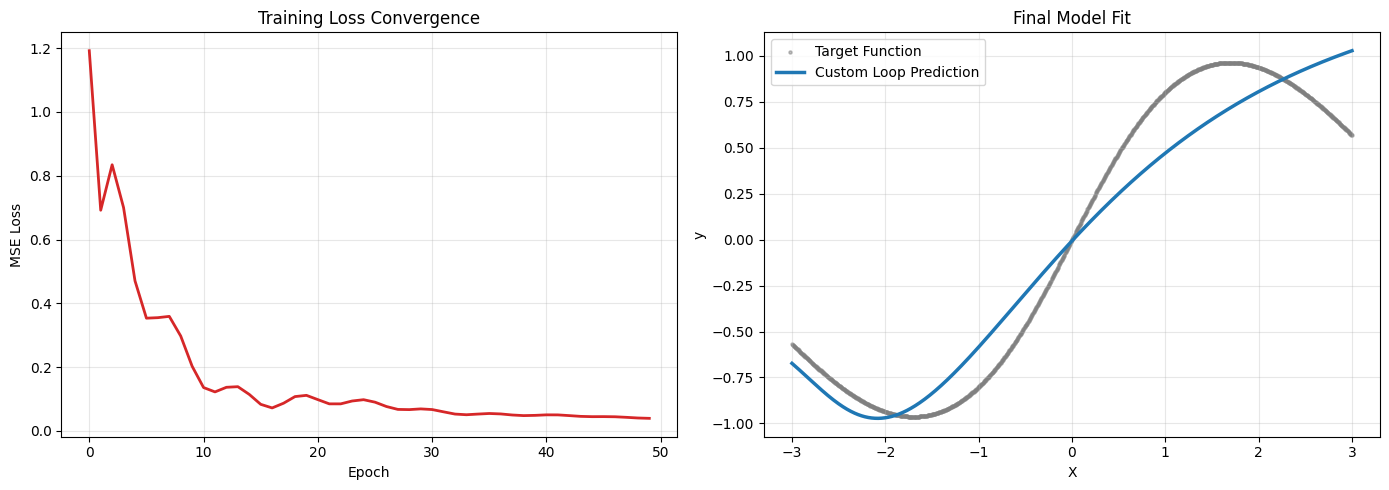

In [9]:
# Cast entire scaling inputs for prediction
X_dev = network.cast_arrays(X_scaled.T)
predictions = network.forward(X_dev)

# Transfer predictions back to CPU numpy for plotting
predictions_cpu = network.asnumpy(predictions)

# Plotting the training loss progression and model predictions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epoch_losses, color='tab:red', linewidth=2)
ax1.set_title("Training Loss Convergence")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.grid(True, alpha=0.3)

ax2.scatter(X, y, s=5, color='gray', alpha=0.5, label='Target Function')
ax2.plot(X, predictions_cpu.T, color='tab:blue', linewidth=2.5, label='Custom Loop Prediction')
ax2.set_title("Final Model Fit")
ax2.set_xlabel("X")
ax2.set_ylabel("y")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()